# Make Conv Autoencoder for XGBoost features, generate bathymetry data from already exsiting paths

## 1. import libs

In [28]:
import copy
import numpy as np
import xarray as xr
from scipy.interpolate import RegularGridInterpolator, interp1d

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import os
import pandas as pd

from sklearn.model_selection import train_test_split
import xarray as xr

## 2. load GEBCO bathymetry data & print

In [29]:
f_bathy = '/Users/jhughes/Downloads/GEBCO_14_Aug_2026_8d63a979c142/gebco_2026_n69.06_s62.94_w-41.46_e-16.03.nc'
data_xr = xr.open_dataset(f_bathy) #returns an xarray, contains a lat, long and elevation value for each point
print(data_xr)
print(data_xr.sizes)
#this is the data the autoencoder will use, elevation will be x

<xarray.Dataset> Size: 36MB
Dimensions:    (lat: 1468, lon: 6103)
Coordinates:
  * lat        (lat) float64 12kB 62.94 62.95 62.95 62.96 ... 69.05 69.05 69.06
  * lon        (lon) float64 49kB -41.46 -41.45 -41.45 ... -16.04 -16.04 -16.03
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) float32 36MB ...
Attributes: (12/37)
    comment:                         The data in the GEBCO_2026 Grid should n...
    Conventions:                     CF-1.6, ACDD-1.3
    creator_email:                   gdacc@seabed2030.org
    creator_name:                    GEBCO through the Nippon Foundation-GEBC...
    creator_type:                    International organisation
    creator_url:                     https://www.gebco.net
    ...                              ...
    project:                         Nippon Foundation - GEBCO Seabed2030 Pro...
    references:                      DOI: 10.5285/4f68d5c7-45eb-f999-e063-708...
    source:                          The GEBCO_2026 Grid

## 3. Extract Arrays & Plot Bathymetry data

Latitude shape: (1468,)
Longitude shape: (6103,)
Elevation shape: (1468, 6103)


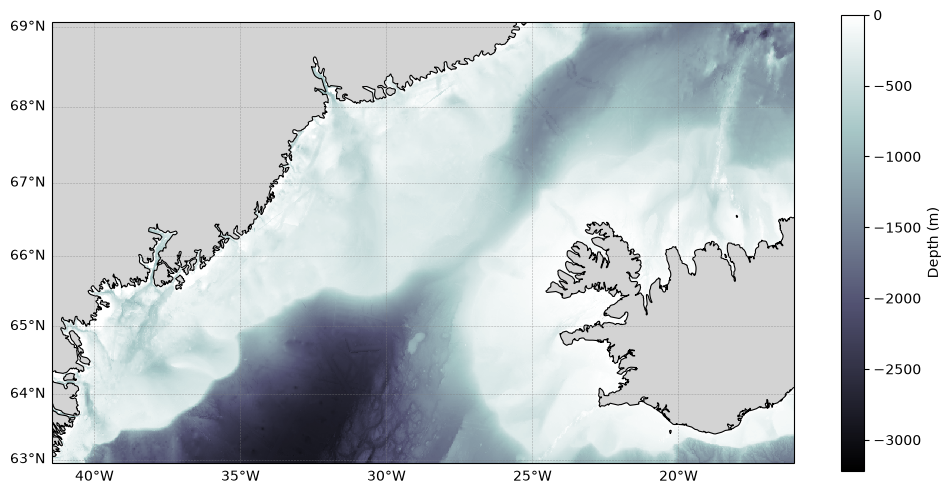

In [30]:
lat = np.asarray(data_xr['lat'])
lon = np.asarray(data_xr['lon'])
elevation = np.asarray(data_xr['elevation'])
print(f'Latitude shape: {lat.shape}')
print(f'Longitude shape: {lon.shape}')
print(f'Elevation shape: {elevation.shape}')

elevation_masked = np.ma.masked_where(elevation > 0, elevation)

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.Mercator())

extent = [lon.min(), lon.max(), lat.min(), lat.max()]
ax.set_extent(extent, crs=ccrs.PlateCarree())

origin = 'lower' if lat[0] < lat[-1] else 'upper'

img = ax.imshow(
    elevation_masked, extent=extent, transform=ccrs.PlateCarree(),
    origin=origin, cmap='bone', vmin=elevation_masked.min(), vmax=0,
    interpolation='nearest'
)

ax.coastlines(resolution='10m', linewidth=0.8, color='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
gl = ax.gridlines(draw_labels=['left', 'bottom'], linewidth=0.4, color='gray', alpha=0.6, linestyle='--')

cbar = plt.colorbar(img, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('Depth (m)')

plt.tight_layout()
plt.show()


## 4. Load Source-Reciever Paths & build Path_sampling

In [62]:
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()
DATA_PATH = os.path.join(HERE, "Data", "BellhopData", "bellhop_monthly_original.csv") #

def load_and_prepare() -> pd.DataFrame:  
    df = pd.read_csv(DATA_PATH)
    valid = (df["tl_bellhop_db"].notna() & np.isfinite(df["tl_bellhop_db"])
             & (df["tl_bellhop_db"] <= 160.0))
    df = df[valid].copy()

    df["residual_db"] = df["tl_bellhop_db"] - df["tl_analytic_db"]
    df["log10_freq_hz"] = np.log10(df["freq_hz"])
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    if "group_id" not in df.columns:
        df["group_id"] = df["source_file"].astype(str) + "_" + df["pair_i"].astype(str)
    return df

df = load_and_prepare()

# One row per unique source-receiver pair (the same pair repeats across freq_hz/month)
path_table = (
    df[['group_id', 'src_lat', 'src_lon', 'rcv_lat', 'rcv_lon', 'range_km']]
    .drop_duplicates(subset='group_id')
    .reset_index(drop=True)
)
print(f"{len(path_table)} unique source-receiver paths in the dataset")

def initial_bearing(lat1, lon1, lat2, lon2):  #computes compass bearing betweeen the points and store as path_table
    """Initial great-circle compass bearing (deg, 0=N, clockwise) from point 1 to point 2."""
    lat1_r, lat2_r = np.radians(lat1), np.radians(lat2)
    dlon_r = np.radians(lon2 - lon1)
    x = np.sin(dlon_r) * np.cos(lat2_r)
    y = np.cos(lat1_r) * np.sin(lat2_r) - np.sin(lat1_r) * np.cos(lat2_r) * np.cos(dlon_r)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

path_table['bearing_deg'] = initial_bearing(
    path_table['src_lat'].values, path_table['src_lon'].values,
    path_table['rcv_lat'].values, path_table['rcv_lon'].values,
)

def sample_paths_from_table(path_table, lat, lon, elevation, step_m=500):
    """
    Sample depth profiles along the ACTUAL source-receiver paths in path_table
    (one path per unique group_id) — same stepping/interpolation as before,
    but the start point, bearing, and length all come from real data.
    """
    R_EARTH = 6371000.0
    interp = RegularGridInterpolator((lat, lon), elevation, bounds_error=False, fill_value=np.nan)

    def destination_point(lat0, lon0, bearing_deg, distance_m):
        lat0_r, lon0_r = np.radians(lat0), np.radians(lon0)
        brng = np.radians(bearing_deg)
        d_r = distance_m / R_EARTH
        lat1_r = np.arcsin(np.sin(lat0_r) * np.cos(d_r) + np.cos(lat0_r) * np.sin(d_r) * np.cos(brng))
        lon1_r = lon0_r + np.arctan2(
            np.sin(brng) * np.sin(d_r) * np.cos(lat0_r),
            np.cos(d_r) - np.sin(lat0_r) * np.sin(lat1_r)
        )
        return np.degrees(lat1_r), np.degrees(lon1_r)

    paths, coords, group_ids = [], [], []
    for row in path_table.itertuples(index=False):
        length_m = row.range_km * 1000
        n_steps = int(length_m // step_m) + 1
        if n_steps < 2:
            continue

        distances = np.arange(n_steps) * step_m
        lat_pts = np.empty(n_steps)
        lon_pts = np.empty(n_steps)
        for i, d in enumerate(distances):
            lat_pts[i], lon_pts[i] = destination_point(row.src_lat, row.src_lon, row.bearing_deg, d)

        depths = interp(np.column_stack([lat_pts, lon_pts]))
        paths.append(depths)
        coords.append((lat_pts, lon_pts))
        group_ids.append(row.group_id)

    return paths, coords, group_ids

def drop_nan_paths(paths, ids):
    keep = [i for i, p in enumerate(paths) if not np.any(np.isnan(p)) and not np.any(p > 0)]
    dropped = len(paths) - len(keep)
    if dropped:
        print(f"Dropped {dropped} paths that left the bathymetry grid / crossed land")
    return [paths[i] for i in keep], [ids[i] for i in keep]



3092 unique source-receiver paths in the dataset


## 5. Generate the Paths

In [69]:
demo_table = path_table.sample(n=10, random_state=2).reset_index(drop=True)  #for the plot
paths, coords, ids_demo = sample_paths_from_table(demo_table, lat, lon, elevation)


## 6. Plot of smapled fepth Profiles

96
154


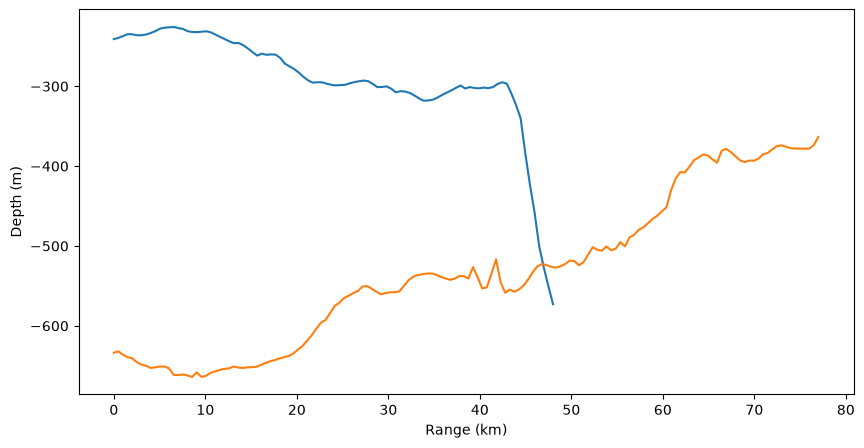

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for path in paths[::5]:
    print(len(path))
    dist = np.linspace(0, 500 * len(path), len(path)) / 1000
    ax.plot(dist, path)
ax.set_xlabel('Range (km)')
ax.set_ylabel('Depth (m)')
plt.show()



## 7. Plot of Paths on MAp

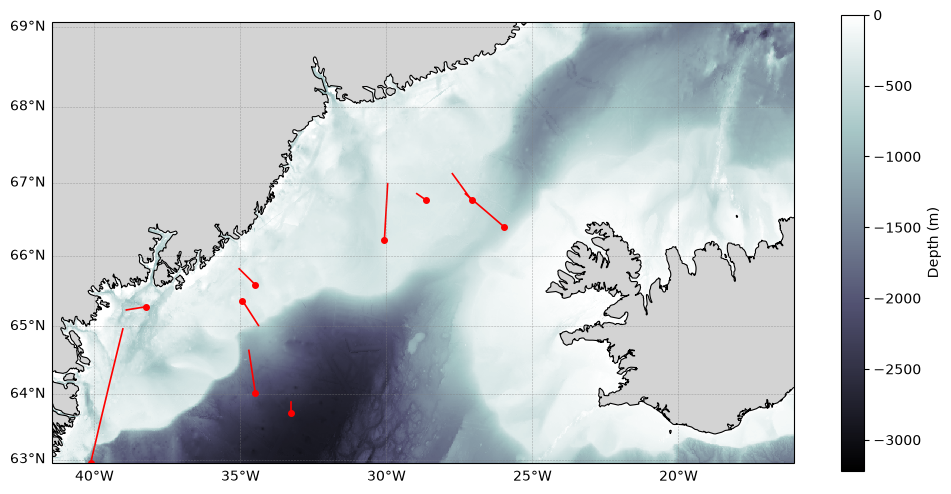

In [71]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.Mercator())

extent = [lon.min(), lon.max(), lat.min(), lat.max()]
ax.set_extent(extent, crs=ccrs.PlateCarree())

origin = 'lower' if lat[0] < lat[-1] else 'upper'

img = ax.imshow(
    elevation_masked, extent=extent, transform=ccrs.PlateCarree(),
    origin=origin, cmap='bone', vmin=elevation_masked.min(), vmax=0,
    interpolation='nearest'
)

for lat_pts, lon_pts in coords:
    ax.plot(lon_pts, lat_pts, transform=ccrs.PlateCarree(), color='r', linewidth=1.2)
    ax.plot(lon_pts[0], lat_pts[0], marker='o', color='r', markersize=4, transform=ccrs.PlateCarree(), zorder=5)

ax.coastlines(resolution='10m', linewidth=0.8, color='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
gl = ax.gridlines(draw_labels=['left', 'bottom'], linewidth=0.4, color='gray', alpha=0.6, linestyle='--')

cbar = plt.colorbar(img, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('Depth (m)')

plt.tight_layout()
plt.show()



## 8. Depth rofile DataSet C;ass

In [ ]:
class DepthProfileDataset(Dataset):
    def __init__(self, paths, n_points=100, mean=None, std=None):
        self.n_points = n_points
        clean_paths = [np.asarray(p) for p in paths if not np.any(np.isnan(p))]
        if len(clean_paths) < len(paths):
            print(f"Dropped {len(paths) - len(clean_paths)} paths containing NaNs.")

        resampled = np.array([self._resample(p, n_points) for p in clean_paths])
        self.trend = resampled.mean(axis=1, keepdims=True)
        detrended = resampled - self.trend

        if mean is None or std is None:
            self.mean = detrended.mean()
            self.std = detrended.std()
        else:
            self.mean = mean
            self.std = std

        normalized = (detrended - self.mean) / self.std
        self.data = torch.tensor(normalized, dtype=torch.float32)
        print(self.data.shape)
        self.trend = torch.tensor(self.trend, dtype=torch.float32)

    @staticmethod
    def _resample(depths, n_points):
        x_old = np.linspace(0, 1, len(depths))
        x_new = np.linspace(0, 1, n_points)
        f = interp1d(x_old, depths, kind='linear')
        return f(x_new)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx]
        return x, x

    def inverse_transform(self, x_normalized, idx=None, trend=None):
        if isinstance(x_normalized, torch.Tensor):
            x_normalized = x_normalized.detach().cpu().numpy()

        detrended = x_normalized * self.std + self.mean

        if trend is not None:
            if isinstance(trend, torch.Tensor):
                trend = trend.detach().cpu().numpy()
            trend_arr = np.asarray(trend)
        elif idx is not None:
            trend_arr = self.trend[idx].numpy()
        else:
            raise ValueError("Must provide either `idx` (to use stored trend) or `trend` explicitly.")

        return detrended + trend_arr
\


Dropped 19 paths that left the bathymetry grid / crossed land
Saved 3073 path embeddings to results/path_embeddings.csv


## 9. Generate train/test/val path sets

In [19]:
train_table, testval_table = train_test_split(path_table, test_size=0.30, random_state=42)
val_table, test_table = train_test_split(testval_table, test_size=0.5, random_state=42)

paths_train, coords_train, ids_train = sample_paths_from_table(train_table, lat, lon, elevation)
paths_val,   coords_val,   ids_val   = sample_paths_from_table(val_table,   lat, lon, elevation)
paths_test,  coords_test,  ids_test  = sample_paths_from_table(test_table,  lat, lon, elevation)

paths_train, ids_train = drop_nan_paths(paths_train, ids_train)
paths_val,   ids_val   = drop_nan_paths(paths_val,   ids_val)
paths_test,  ids_test  = drop_nan_paths(paths_test,  ids_test)


Dropped 16 paths that left the bathymetry grid / crossed land
Dropped 2 paths that left the bathymetry grid / crossed land
Dropped 1 paths that left the bathymetry grid / crossed land


## 10. Hyperparams and Data Loader

In [20]:
N_POINTS = 100
LATENT_DIM = 8
BATCH_SIZE = 32
print(f"Batch size {BATCH_SIZE}")

N_EPOCHS = 500
LR = 1e-4
PATIENCE = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = DepthProfileDataset(paths_train, n_points=N_POINTS)
print(len(train_ds))
print(train_ds.data.shape)

val_ds = DepthProfileDataset(paths_val, n_points=N_POINTS, mean=train_ds.mean, std=train_ds.std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


Batch size 32
2148
torch.Size([2148, 100])


## 11. Convoloutional Autoencoder

In [21]:
filters = 5
neighbouring_points = 9

class ConvAutoencoder(nn.Module):
    def __init__(self, n_points, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Unflatten(1, (1, n_points)),
            nn.Conv1d(1, filters, neighbouring_points, padding=4),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(filters * n_points, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, filters * n_points),
            nn.ReLU(),
            nn.Unflatten(1, (filters, n_points)),
            nn.Conv1d(filters, 1, neighbouring_points, padding=4),
            nn.Flatten(),
        )

    def forward(self, x):
        z2 = self.encoder(x)
        x_hat2 = self.decoder(z2)
        return x_hat2


## 12. Instantiate model

In [22]:
model2 = ConvAutoencoder(N_POINTS, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=LR)
criterion = nn.MSELoss()


## 13. Training Loop

In [23]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_model_state = None
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    model2.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        x_hat2 = model2(x)
        loss = criterion(x_hat2, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    train_loss /= len(train_ds)

    model2.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            x_hat2 = model2(x)
            loss = criterion(x_hat2, y)
            val_loss += loss.item() * x.size(0)
    val_loss /= len(val_ds)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model2.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} "
                  f"(no improvement for {PATIENCE} epochs, best val loss: {best_val_loss:.4f})")
            break

model2.load_state_dict(best_model_state)
print(f"Restored best model with val loss: {best_val_loss:.4f}")


Early stopping at epoch 364 (no improvement for 10 epochs, best val loss: 0.0192)
Restored best model with val loss: 0.0192


## 14. Loss Curves and Reconstruction

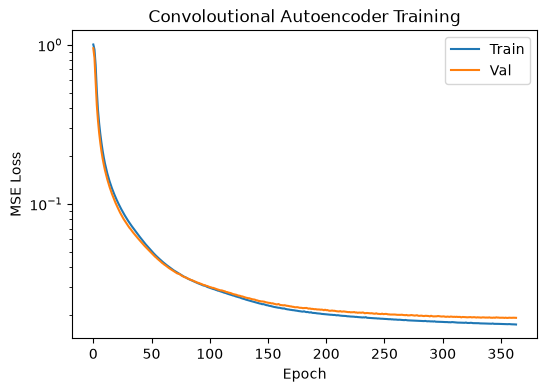

AttributeError: 'DepthProfileDataset' object has no attribute 'inverse_transform'

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.title('Convoloutional Autoencoder Training')
plt.show()

model2.eval()
x, _ = val_ds[0]
with torch.no_grad():
    x_hat2 = model2(x.unsqueeze(0).to(device)).cpu().squeeze(0)

absolute_true = val_ds.inverse_transform(x, idx=0)
absolute_recon = val_ds.inverse_transform(x_hat2, idx=0)

plt.figure(figsize=(8, 4))
plt.plot(absolute_true, label='True depth')
plt.plot(absolute_recon, label='Reconstructed', linestyle='--')
plt.xlabel('Point along path')
plt.ylabel('Depth (m)')
plt.legend()
plt.title('Convoloutional Autoencoder Reconstruction')
plt.show()


## 15. Wrap the Autoencoder in a fucntion

In [25]:
def train_conv_autoencoder(filters, neighbouring_points, n_points=N_POINTS, latent_dim=LATENT_DIM,
                            n_epochs=N_EPOCHS, lr=LR, patience=PATIENCE):
    padding = (neighbouring_points - 1) // 2

    class _ConvAutoencoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Unflatten(1, (1, n_points)),
                nn.Conv1d(1, filters, neighbouring_points, padding=padding),
                nn.ReLU(),
                nn.Flatten(),
                nn.Linear(filters * n_points, latent_dim),
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, filters * n_points),
                nn.ReLU(),
                nn.Unflatten(1, (filters, n_points)),
                nn.Conv1d(filters, 1, neighbouring_points, padding=padding),
                nn.Flatten(),
            )

        def forward(self, x):
            return self.decoder(self.encoder(x))

    model = _ConvAutoencoder().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(n_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                val_loss += criterion(model(x), y).item() * x.size(0)
        val_loss /= len(val_ds)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    print(f"filters={filters:>3} | neighbouring_points={neighbouring_points:>3} | best val loss: {best_val_loss:.5f}")
    return best_val_loss


## 16. Visualise LAtent Space

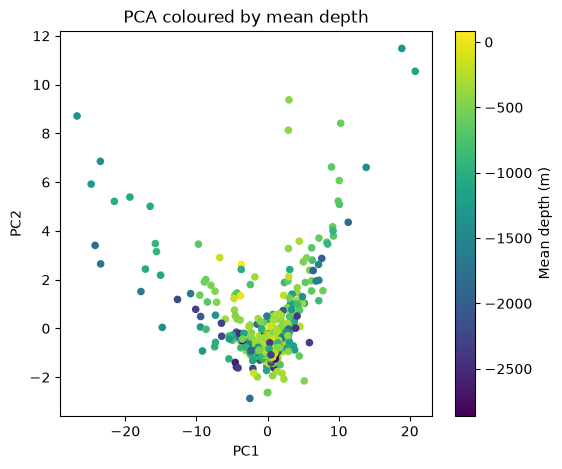

[0.7679109  0.10220735]


In [26]:
from sklearn.decomposition import PCA

model2.eval()
with torch.no_grad():
    latents = model2.encoder(val_ds.data.to(device)).cpu().numpy()

mean_depth = val_ds.trend.squeeze(1).numpy()

pca = PCA(n_components=2)
latents_2d = pca.fit_transform(latents)

plt.figure(figsize=(6, 5))
sc = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=mean_depth, s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA coloured by mean depth')
cbar = plt.colorbar(sc)
cbar.set_label('Mean depth (m)')
plt.show()
print(pca.explained_variance_ratio_)


## 17. Extract Features from DataSet

In [27]:
def extract_embeddings(model2, dataset):
    model2.eval()
    with torch.no_grad():
        features = model2.encoder(dataset.data.to(device))
    return features.cpu().numpy()

paths_all, coords_all, ids_all = sample_paths_from_table(path_table, lat, lon, elevation)
paths_all, ids_all = drop_nan_paths(paths_all, ids_all)

all_ds = DepthProfileDataset(paths_all, n_points=N_POINTS, mean=train_ds.mean, std=train_ds.std)
all_embeddings = extract_embeddings(model2, all_ds)

embed_cols = [f'feaatures{i}' for i in range(all_embeddings.shape[1])]
embeddings_df = pd.DataFrame(all_embeddings, columns=embed_cols)
embeddings_df.insert(0, 'group_id', ids_all)

os.makedirs('results', exist_ok=True)
embeddings_df.to_csv('results/path_embeddings.csv', index=False)
print(f"Saved {len(embeddings_df)} path embeddings to results/path_embeddings.csv")

embeddings_df


Dropped 19 paths that left the bathymetry grid / crossed land
Saved 3073 path embeddings to results/path_embeddings.csv


,group_id,feaatures0,feaatures1,feaatures2,feaatures3,feaatures4,feaatures5,feaatures6,feaatures7
0,bellhop_long_range_Apr.csv_0,-1.916405,1.388455,2.722597,-4.530007,1.402291,-2.837972,-0.994989,-1.122084
1,bellhop_long_range_Apr.csv_1,0.193168,0.481270,-1.065915,0.424014,0.769596,-0.024297,0.406321,0.094790
2,bellhop_long_range_Apr.csv_2,-0.867390,5.867610,4.494672,-3.698835,4.014547,-7.466581,-1.498065,-1.995205
3,bellhop_long_range_Apr.csv_3,-0.924481,1.846485,3.624504,-2.344408,-0.862872,1.892116,-1.260558,-1.244534
4,bellhop_long_range_Apr.csv_4,-3.249095,2.588125,3.317211,-4.194523,-1.240438,2.694322,-1.274934,-2.374739
...,...,...,...,...,...,...,...,...,...
3068,bellhop_short_range_Sep.csv_195,-0.588942,0.743059,0.940370,-1.142765,0.208771,0.560375,-0.297140,-0.740275
3069,bellhop_short_range_Sep.csv_196,0.655273,0.880929,-0.200023,-0.115966,1.004830,-0.142848,0.089829,-0.594471
3070,bellhop_short_range_Sep.csv_197,-1.110564,1.626628,3.076384,-2.757969,0.209856,0.121742,-0.867297,-1.444052
3071,bellhop_short_range_Sep.csv_198,0.041611,0.148106,0.024625,-0.028291,0.874170,-0.127884,0.132139,-0.093593
